Districts loaded: 30

Class Breaks
1 <= -0.8994885282387691
2 <= -0.48421594315769484
3 <= -0.23515223943710445
4 <= -0.017177389604720376
5 > -0.017177389604720376

Saved:
district_choropleth.geojson
district_choropleth.shp


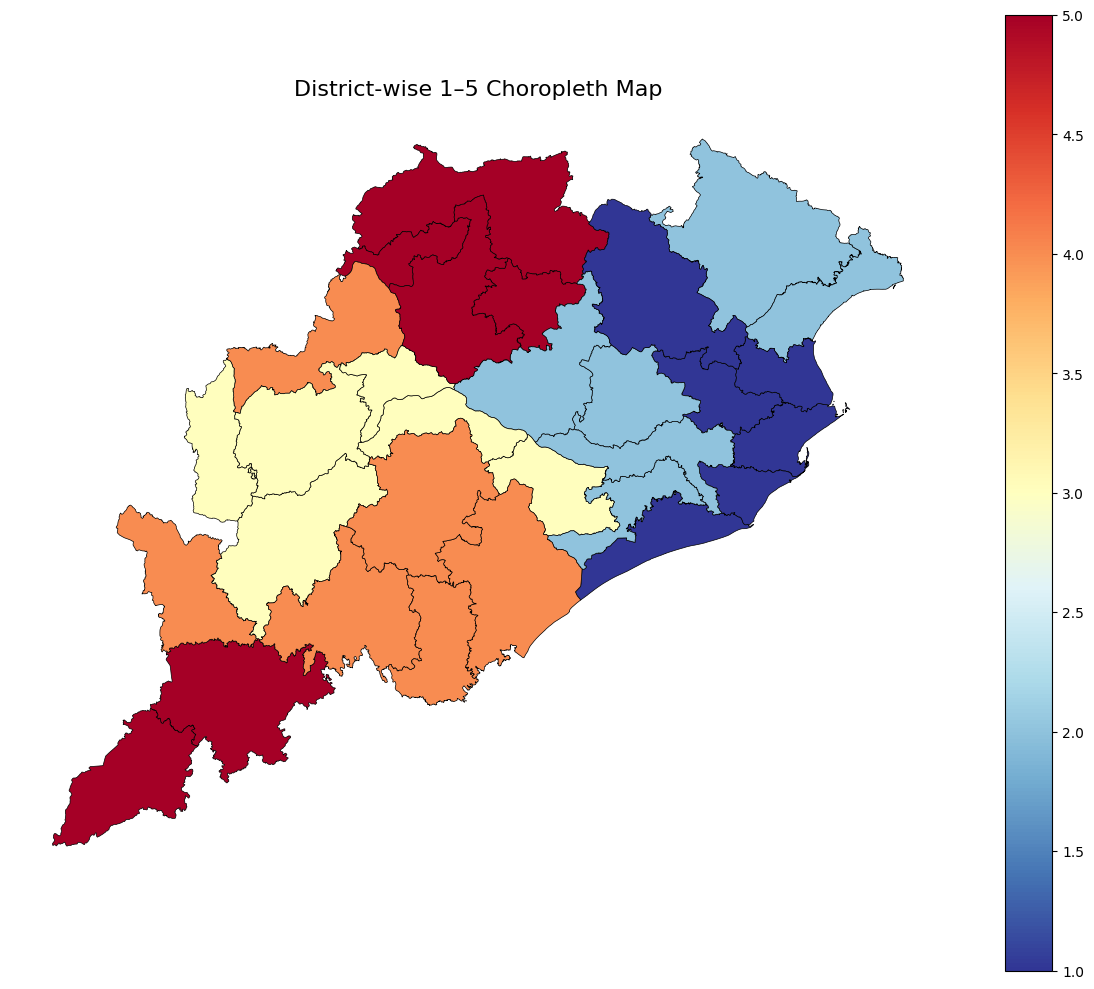


PNG map saved.


In [3]:
# =============================================================================
# RASTER TO 1–5 DISTRICT CHOROPLETH VECTOR MAP
# =============================================================================
# Uses:
# - Raster (.tif)
# - District boundaries (.geojson)
#
# Output:
# - District-wise mean raster values
# - 1–5 classified choropleth vector layer
# - GeoJSON + Shapefile output
# - Choropleth map visualization
#
# =============================================================================

import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt

from rasterstats import zonal_stats

# =============================================================================
# INPUT FILES
# =============================================================================

raster_path = r"YOUR_RASTER.tif"
district_path = r"district.geojson"

output_geojson = r"district_choropleth.geojson"
output_shp = r"district_choropleth.shp"

# =============================================================================
# LOAD DISTRICT BOUNDARIES
# =============================================================================

gdf = gpd.read_file(district_path)

print("Districts loaded:", len(gdf))

# =============================================================================
# COMPUTE DISTRICT-WISE MEAN VALUES
# =============================================================================

stats = zonal_stats(
    district_path,
    raster_path,
    stats=['mean'],
    geojson_out=False,
    nodata=-9999
)

# Add mean values to GeoDataFrame
gdf['mean_val'] = [s['mean'] for s in stats]

# =============================================================================
# HANDLE NULLS
# =============================================================================

gdf = gdf[gdf['mean_val'].notnull()]

# =============================================================================
# CREATE 1–5 CLASSES USING QUANTILES
# =============================================================================

q1 = gdf['mean_val'].quantile(0.20)
q2 = gdf['mean_val'].quantile(0.40)
q3 = gdf['mean_val'].quantile(0.60)
q4 = gdf['mean_val'].quantile(0.80)

print("\nClass Breaks")
print("1 <=", q1)
print("2 <=", q2)
print("3 <=", q3)
print("4 <=", q4)
print("5 >", q4)

# =============================================================================
# CLASSIFICATION FUNCTION
# =============================================================================

def classify(val):

    if val <= q1:
        return 1

    elif val <= q2:
        return 2

    elif val <= q3:
        return 3

    elif val <= q4:
        return 4

    else:
        return 5

gdf['class_1_5'] = gdf['mean_val'].apply(classify)

# =============================================================================
# SAVE OUTPUT VECTOR LAYERS
# =============================================================================

gdf.to_file(output_geojson, driver='GeoJSON')
gdf.to_file(output_shp)

print("\nSaved:")
print(output_geojson)
print(output_shp)

# =============================================================================
# PLOT CHOROPLETH MAP
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    column='class_1_5',
    cmap='RdYlBu_r',
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title("District-wise 1–5 Choropleth Map", fontsize=16)
ax.axis('off')

plt.tight_layout()
plt.show()

# =============================================================================
# OPTIONAL: SAVE PNG
# =============================================================================

fig.savefig(
    "district_choropleth.png",
    dpi=300,
    bbox_inches='tight'
)

print("\nPNG map saved.")

# =============================================================================
# OUTPUT ATTRIBUTES
# =============================================================================
# mean_val   = district mean raster value
# class_1_5  = choropleth class
#
# 1 = Very Low
# 2 = Low
# 3 = Moderate
# 4 = High
# 5 = Very High
# =============================================================================

In [1]:
import pandas as pd

# Read CSV
df = pd.read_csv("risk.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Automatically find the risk column
risk_col = [c for c in df.columns if "risk" in c.lower()][0]

# 5-class Jenks-like classification for your additive scores (5–12)
def jenks_class(x):
    if x <= 5:
        return 1
    elif x <= 7:
        return 2
    elif x <= 9:
        return 3
    elif x <= 11:
        return 4
    else:
        return 5

df["jenks_class"] = df[risk_col].apply(jenks_class)

# Save result
df.to_csv("risk_jenks.csv", index=False)

# View result
print(df[["dtname", risk_col, "jenks_class"]])

# Class counts
print("\nClass Counts:")
print(df["jenks_class"].value_counts().sort_index())

            dtname  total_risk  jenks_class
0           Anugul          10            4
1         Balangir           7            2
2        Baleshwar          11            4
3          Bargarh           8            3
4          Bhadrak          10            4
5            Boudh           8            3
6          Cuttack           9            3
7          Deogarh           9            3
8        Dhenkanal          10            4
9         Gajapati           8            3
10          Ganjam           9            3
11  Jagatsinghapur          10            4
12         Jajapur          10            4
13      Jharsuguda           8            3
14       Kalahandi           7            2
15       Kandhamal           7            2
16      Kendrapara          10            4
17       Kendujhar          10            4
18         Khordha           9            3
19         Koraput           4            1
20      Malkangiri           7            2
21      Mayurbhanj           9  

In [ ]:
!pip install mapclassify